# Digital Image Processing Toolkit

This notebook demonstrates, end-to-end, the techniques covered in a typical Digital Image Processing course and applies them the way they'd be used in a real biomedical imaging pipeline:

1. Image Fundamentals (grayscale, histograms, histogram equalization, CLAHE)
2. Spatial Domain Filtering (smoothing, sharpening, edge detection)
3. Frequency Domain Processing (2D FFT, ideal/Gaussian low-pass & high-pass filters)
4. Noise Modeling & Restoration (Gaussian/salt-and-pepper/speckle noise, Wiener filter, non-local means)
5. Morphological Image Processing (erosion, dilation, opening, closing, boundary extraction)
6. Segmentation (Otsu thresholding, Canny, K-means, watershed, region-property filtering)
7. A mini end-to-end pipeline that chains several of the above together



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy import ndimage, fftpack
from scipy.signal import wiener
from skimage import data, exposure, filters, morphology, segmentation, measure, restoration, color, feature
from skimage.util import random_noise

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['image.cmap'] = 'gray'
np.random.seed(0)

def show(images, titles, cmap='gray', figsize=None):
    n = len(images)
    figsize = figsize or (4 * n, 4.2)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, im, t in zip(axes, images, titles):
        ax.imshow(im, cmap=cmap)
        ax.set_title(t, fontsize=11)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print('Environment ready.')

Environment ready.


## 0. Load an Image — Your Own, or a Built-in Sample

Set `IMAGE_PATH` to a file on disk (X-ray, MRI slice, photo, anything) and it will be used automatically.
Leave it as `None` to fall back to a built-in sample — `'medical'` uses a Shepp-Logan MRI-style phantom,
`'general'` uses a standard grayscale test photo.


Image shape: (400, 400)  dtype: float64  range: (np.float64(0.0), np.float64(1.0))


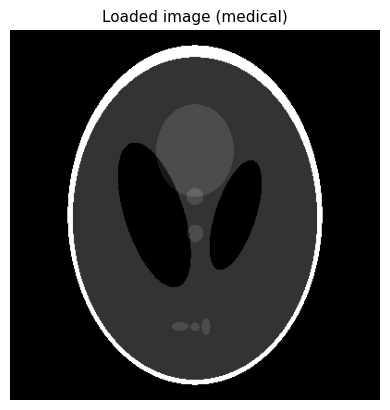

In [2]:
IMAGE_PATH = None          # e.g. r"C:\Users\you\Desktop\mri_slice.png"
SAMPLE_KIND = 'medical'    # 'medical' or 'general' — only used if IMAGE_PATH is None

def load_image(path=None, sample_kind='medical'):
    if path:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Could not read image at {path}")
        return exposure.rescale_intensity(img.astype(np.float64), out_range=(0, 1))
    if sample_kind == 'medical':
        img = data.shepp_logan_phantom()          # MRI-like phantom, values in [0,1]
    else:
        img = data.camera().astype(np.float64) / 255.0
    return img

image = load_image(IMAGE_PATH, SAMPLE_KIND)
print('Image shape:', image.shape, ' dtype:', image.dtype, ' range:', (image.min(), image.max()))
show([image], [f'Loaded image ({SAMPLE_KIND if not IMAGE_PATH else "custom"})'])

## 1. Image Fundamentals — Histograms & Contrast Enhancement

Histograms show the distribution of intensity values. **Histogram equalization** spreads out the most
frequent intensity values, boosting global contrast — useful for underexposed X-rays. **CLAHE**
(Contrast Limited Adaptive Histogram Equalization) does this locally, in small tiles, which avoids
over-amplifying noise in flat regions — the standard choice in medical imaging.


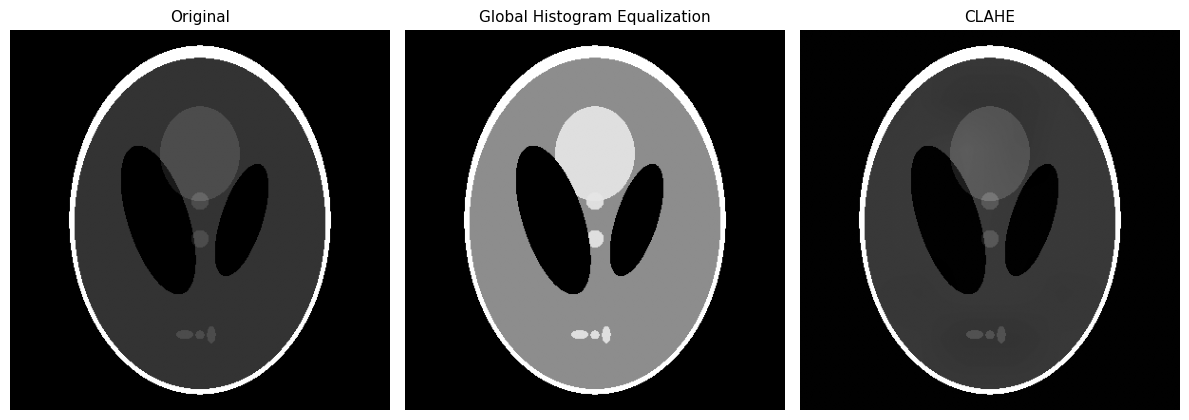

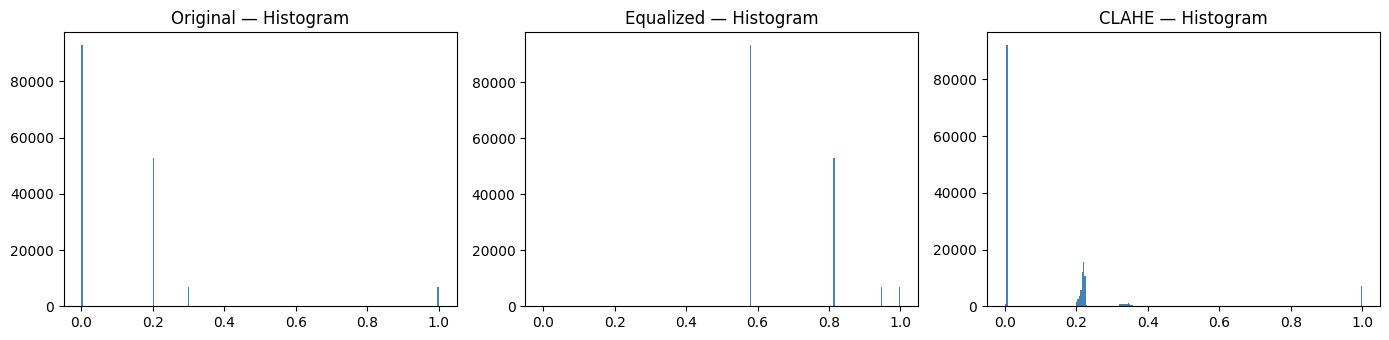

In [3]:
img_eq = exposure.equalize_hist(image)
img_clahe = exposure.equalize_adapthist(image, clip_limit=0.03)

show([image, img_eq, img_clahe], ['Original', 'Global Histogram Equalization', 'CLAHE'])

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, im, t in zip(axes, [image, img_eq, img_clahe], ['Original', 'Equalized', 'CLAHE']):
    ax.hist(im.ravel(), bins=256, range=(0, 1), color='steelblue')
    ax.set_title(f'{t} — Histogram')
plt.tight_layout()
plt.show()

## 2. Spatial Domain Filtering

### 2.1 Smoothing (low-pass)
Mean, Gaussian and median filters all blur the image, but behave differently: mean/Gaussian blur noise
*and* edges together, while the median filter preserves edges better and is especially good against
salt-and-pepper noise.

### 2.2 Sharpening
Unsharp masking and the Laplacian both accentuate edges/fine detail by adding back a high-frequency
component that smoothing would otherwise remove.

### 2.3 Edge Detection
Sobel/Prewitt estimate the gradient magnitude; Canny adds non-maximum suppression and hysteresis
thresholding for thin, well-localized edges — the standard first step before segmentation.


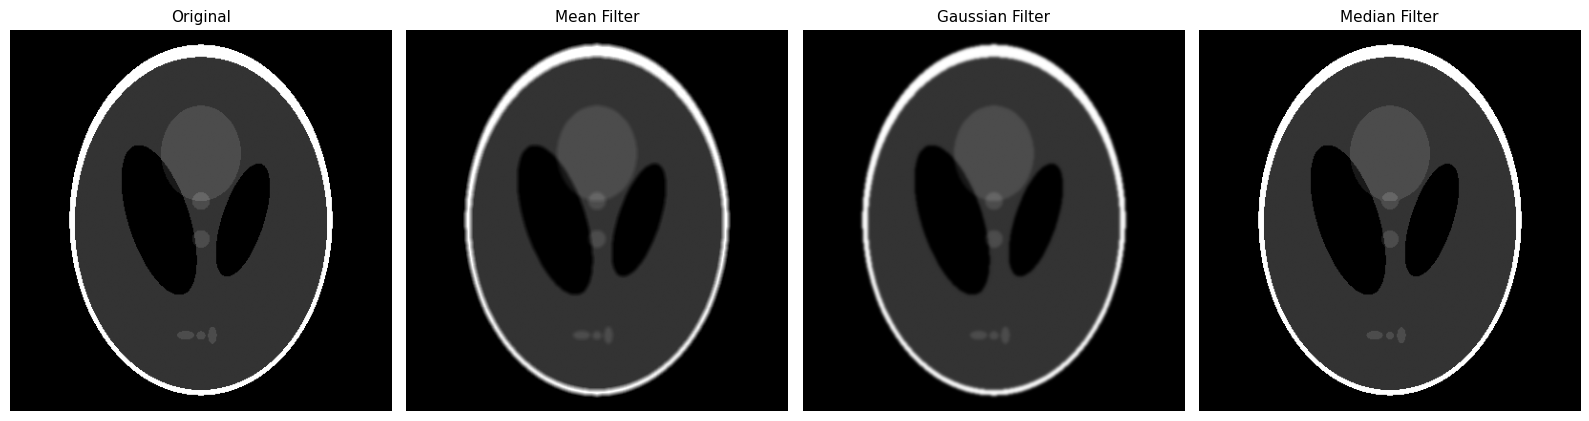

In [4]:
mean_blur = ndimage.uniform_filter(image, size=5)
gauss_blur = ndimage.gaussian_filter(image, sigma=1.5)
median_blur = ndimage.median_filter(image, size=5)

show([image, mean_blur, gauss_blur, median_blur],
     ['Original', 'Mean Filter', 'Gaussian Filter', 'Median Filter'])

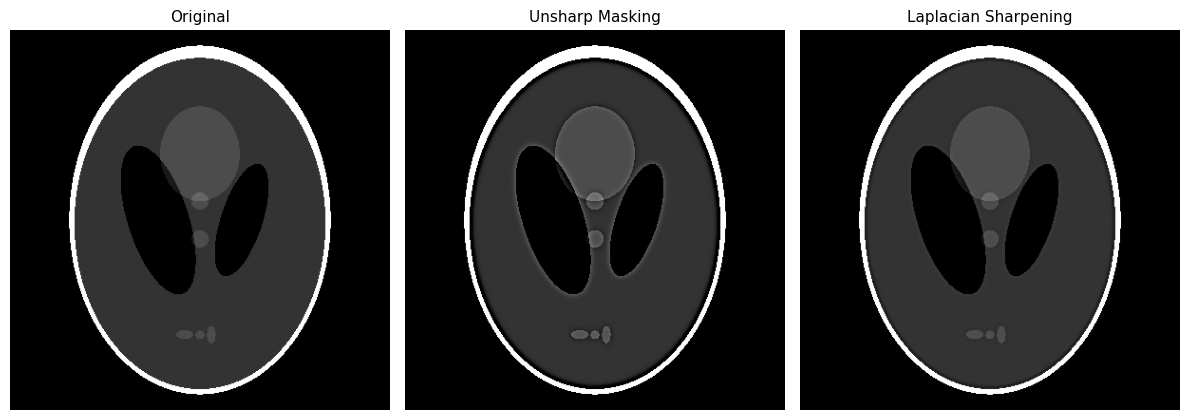

In [5]:
unsharp = filters.unsharp_mask(image, radius=3, amount=1.5)
laplacian = ndimage.laplace(gauss_blur)
sharpened_laplace = np.clip(image - laplacian, 0, 1)

show([image, unsharp, sharpened_laplace], ['Original', 'Unsharp Masking', 'Laplacian Sharpening'])

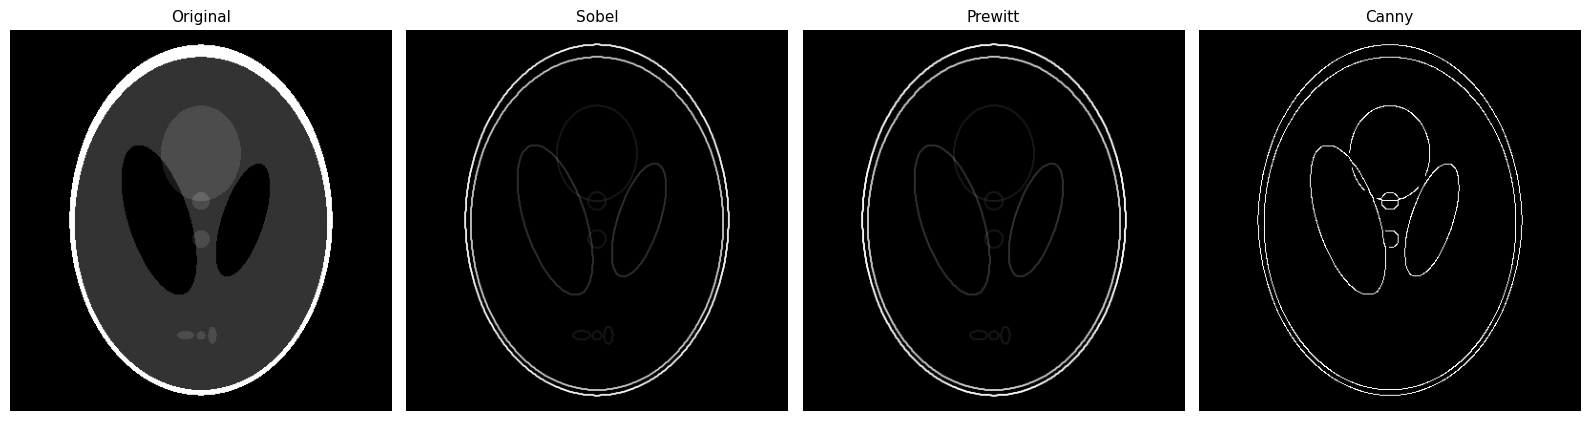

In [6]:
sobel = filters.sobel(image)
prewitt = filters.prewitt(image)
canny = feature.canny(image, sigma=1.5)

show([image, sobel, prewitt, canny], ['Original', 'Sobel', 'Prewitt', 'Canny'])

## 3. Frequency Domain Processing

Every image can be represented as a sum of sinusoids of different frequencies (the 2D Fourier Transform).
Low frequencies encode smooth/slowly-varying regions; high frequencies encode edges and fine texture.

Filtering "in frequency" means: FFT → multiply by a mask → inverse FFT.
- **Low-pass** keeps the center (low frequencies) → smoothing, same effect as spatial blurring but with
  exact frequency-cutoff control.
- **High-pass** keeps the outer ring (high frequencies) → edge/detail enhancement.


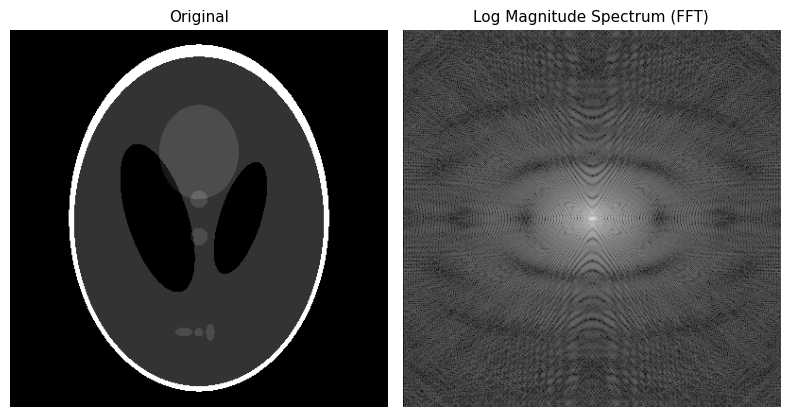

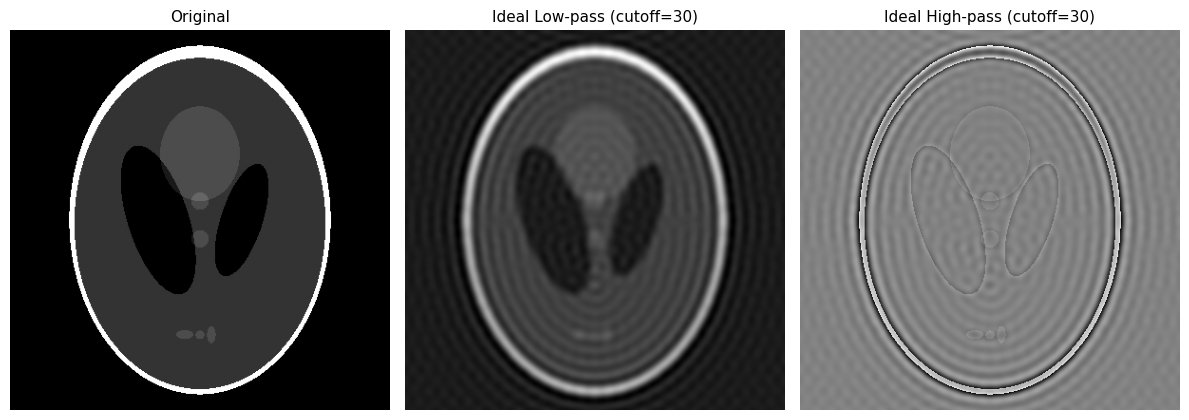

In [7]:
def fft_magnitude(img):
    F = fftpack.fftshift(fftpack.fft2(img))
    return np.log1p(np.abs(F)), F

def make_circular_mask(shape, cutoff, lowpass=True):
    rows, cols = shape
    cy, cx = rows // 2, cols // 2
    Y, X = np.ogrid[:rows, :cols]
    dist = np.sqrt((Y - cy) ** 2 + (X - cx) ** 2)
    mask = dist <= cutoff if lowpass else dist > cutoff
    return mask.astype(np.float64)

mag_spectrum, F = fft_magnitude(image)

lp_mask = make_circular_mask(image.shape, cutoff=30, lowpass=True)
hp_mask = make_circular_mask(image.shape, cutoff=30, lowpass=False)

img_lowpass = np.real(fftpack.ifft2(fftpack.ifftshift(F * lp_mask)))
img_highpass = np.real(fftpack.ifft2(fftpack.ifftshift(F * hp_mask)))
img_highpass = exposure.rescale_intensity(img_highpass, out_range=(0, 1))

show([image, mag_spectrum], ['Original', 'Log Magnitude Spectrum (FFT)'])
show([image, img_lowpass, img_highpass],
     ['Original', 'Ideal Low-pass (cutoff=30)', 'Ideal High-pass (cutoff=30)'])

## 4. Noise Modeling & Restoration

We simulate the three noise types most relevant to imaging systems:
- **Gaussian** — thermal/electronic sensor noise (typical in CT/MRI reconstruction)
- **Salt & pepper** — dead/saturated pixels, transmission errors
- **Speckle** — multiplicative noise characteristic of **ultrasound** imaging

...then restore with matched filters: median for salt-and-pepper, Wiener/Gaussian for additive
Gaussian noise, and Non-Local Means for a general-purpose denoiser that preserves texture better
than a plain Gaussian blur.


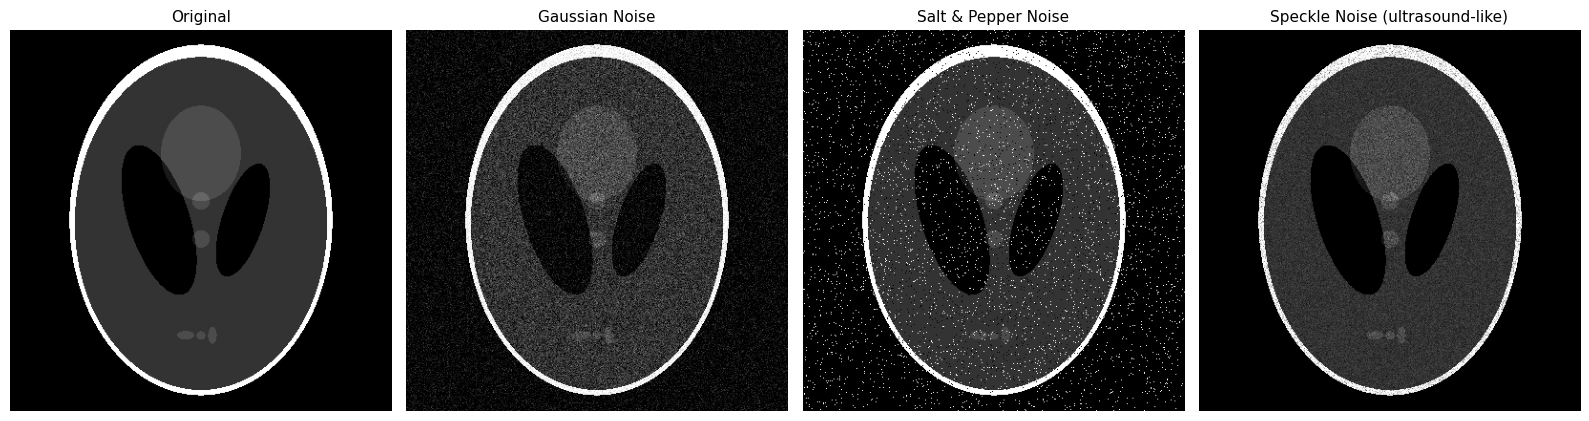

In [8]:
noisy_gaussian = random_noise(image, mode='gaussian', var=0.01)
noisy_sp = random_noise(image, mode='s&p', amount=0.05)
noisy_speckle = random_noise(image, mode='speckle', var=0.05)

show([image, noisy_gaussian, noisy_sp, noisy_speckle],
     ['Original', 'Gaussian Noise', 'Salt & Pepper Noise', 'Speckle Noise (ultrasound-like)'])

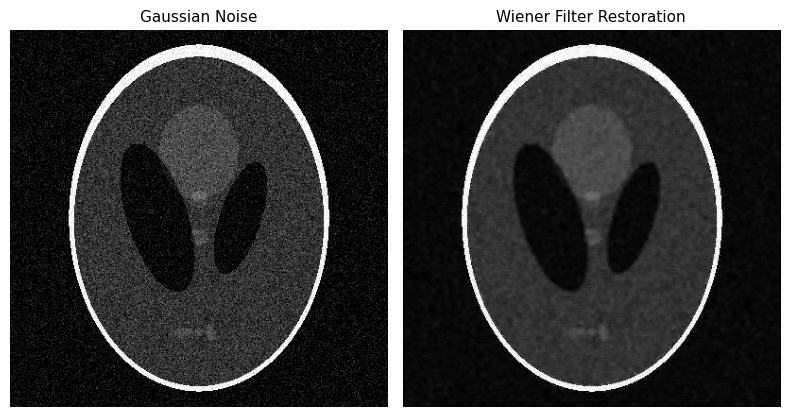

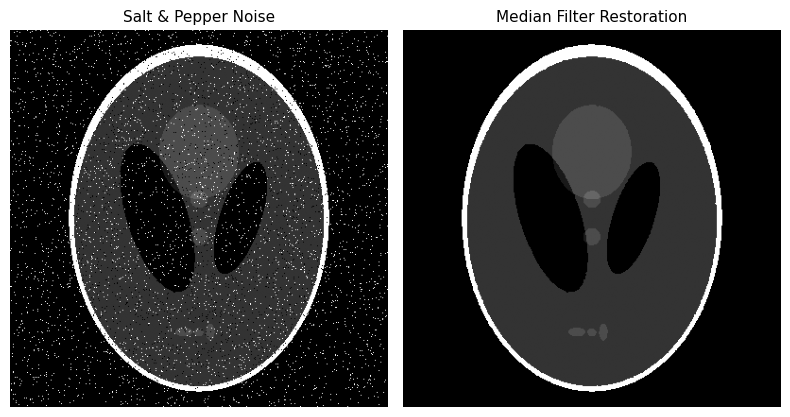

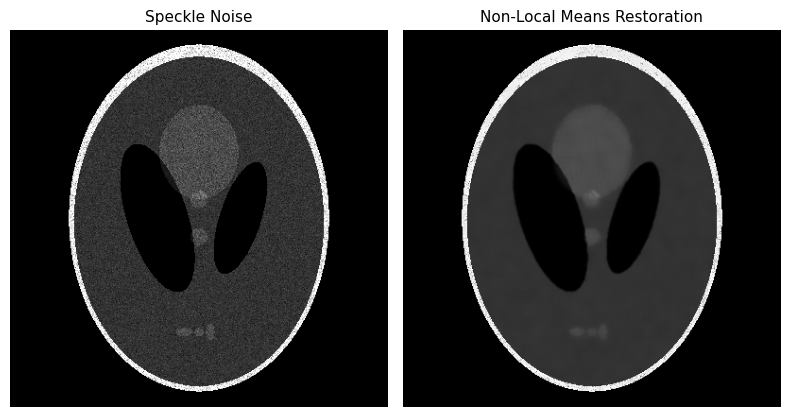

In [9]:
restored_wiener = wiener(noisy_gaussian, mysize=5)
restored_median = ndimage.median_filter(noisy_sp, size=3)
restored_nlm = restoration.denoise_nl_means(noisy_speckle, h=0.08, fast_mode=True,
                                             patch_size=5, patch_distance=6)

show([noisy_gaussian, restored_wiener], ['Gaussian Noise', 'Wiener Filter Restoration'])
show([noisy_sp, restored_median], ['Salt & Pepper Noise', 'Median Filter Restoration'])
show([noisy_speckle, restored_nlm], ['Speckle Noise', 'Non-Local Means Restoration'])

## 5. Morphological Image Processing

Morphological operations work on binary (or grayscale) images using a structuring element:
- **Erosion** shrinks bright regions / removes small bright noise
- **Dilation** grows bright regions / fills small holes
- **Opening** = erosion → dilation: removes small objects while preserving overall shape
- **Closing** = dilation → erosion: fills small holes/gaps while preserving overall shape

These are typically applied *after* segmentation to clean up a binary mask before measuring
regions of interest.


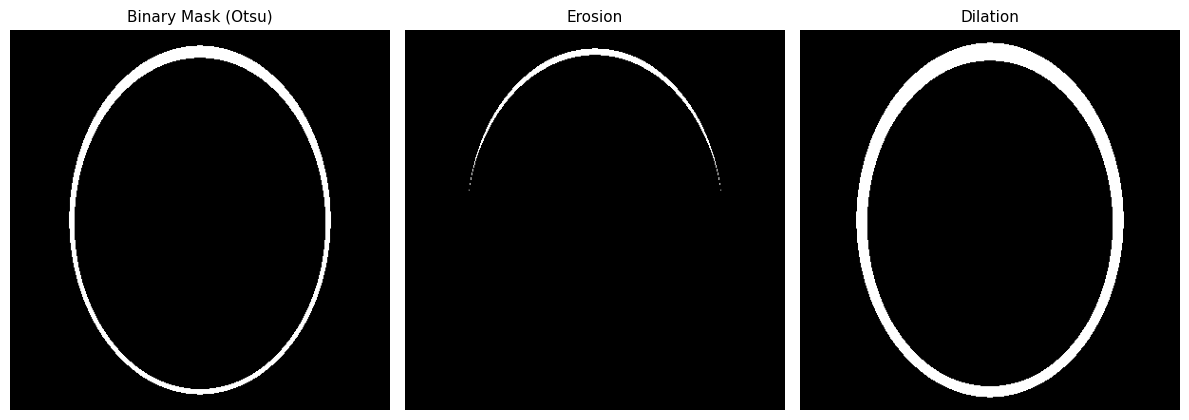

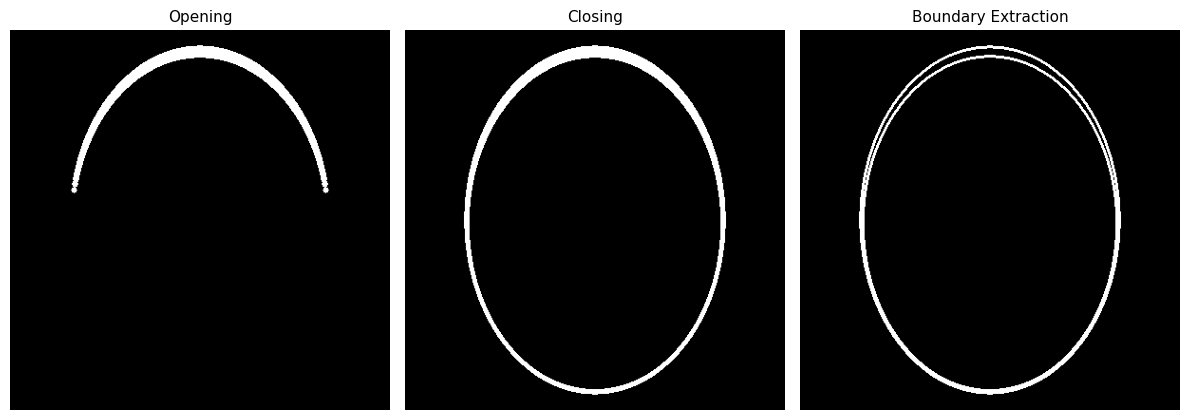

In [10]:
binary = image > filters.threshold_otsu(image)
selem = morphology.disk(3)

eroded = morphology.erosion(binary, selem)
dilated = morphology.dilation(binary, selem)
opened = morphology.opening(binary, selem)
closed = morphology.closing(binary, selem)
boundary = binary ^ eroded   # boundary extraction: original minus eroded

show([binary, eroded, dilated], ['Binary Mask (Otsu)', 'Erosion', 'Dilation'])
show([opened, closed, boundary], ['Opening', 'Closing', 'Boundary Extraction'])

## 6. Segmentation

Four common approaches, each useful in different situations:
- **Otsu thresholding** — fast, global, works when foreground/background intensities are well separated
- **Canny + region filling** — edge-based, useful when regions have weak but well-defined borders
- **K-means clustering** — groups pixels by intensity into *k* clusters, useful for multi-tissue segmentation
- **Watershed** — treats the image as a topographic surface and "floods" it from markers; good for
  touching/overlapping objects (e.g. cell nuclei, adjacent lesions)

We finish by using `regionprops` to filter detected regions by shape descriptors (area, eccentricity) —
the same idea used to isolate a tumor-like region from background clutter in a segmentation mask.


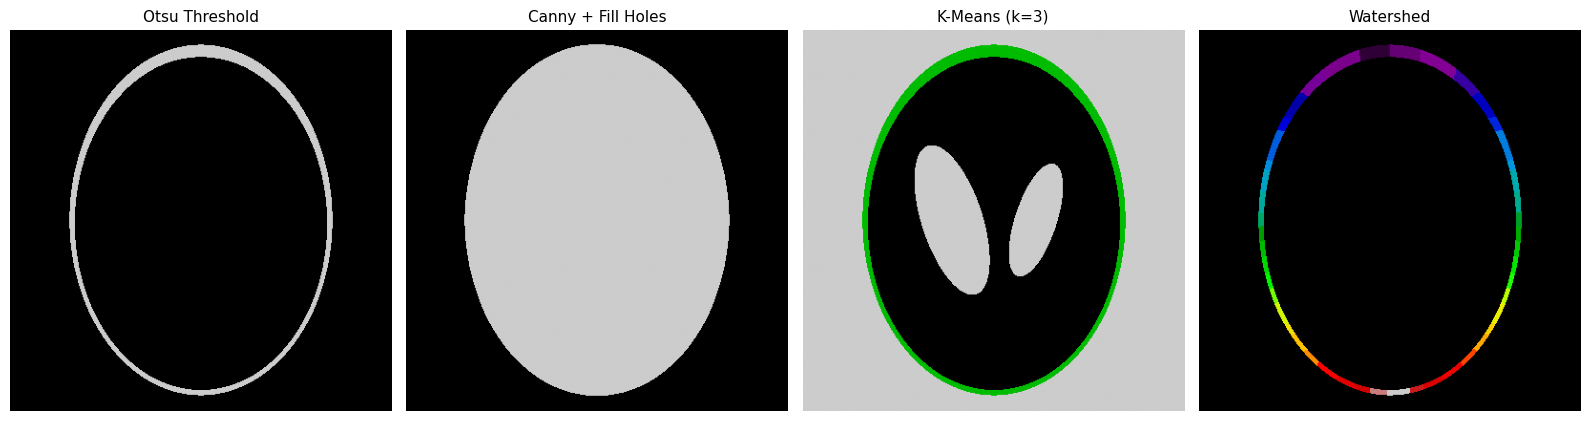

In [11]:
# Otsu
otsu_mask = image > filters.threshold_otsu(image)

# Canny + fill
edges = feature.canny(image, sigma=2)
filled = ndimage.binary_fill_holes(edges)

# K-means (k=3) via simple intensity clustering
from sklearn.cluster import KMeans
flat = image.reshape(-1, 1)
km = KMeans(n_clusters=3, n_init=4, random_state=0).fit(flat)
kmeans_seg = km.labels_.reshape(image.shape)

# Watershed from local maxima markers
distance = ndimage.distance_transform_edt(otsu_mask)
coords = feature.peak_local_max(distance, min_distance=15, labels=otsu_mask)
mask_markers = np.zeros(distance.shape, dtype=bool)
mask_markers[tuple(coords.T)] = True
markers, _ = ndimage.label(mask_markers)
ws_labels = segmentation.watershed(-distance, markers, mask=otsu_mask)

show([otsu_mask, filled, kmeans_seg, ws_labels],
     ['Otsu Threshold', 'Canny + Fill Holes', 'K-Means (k=3)', 'Watershed'],
     cmap='nipy_spectral')

Found 1 regions, 1 above area threshold.
  label=  1  area=  6990  eccentricity=0.664  solidity=0.088


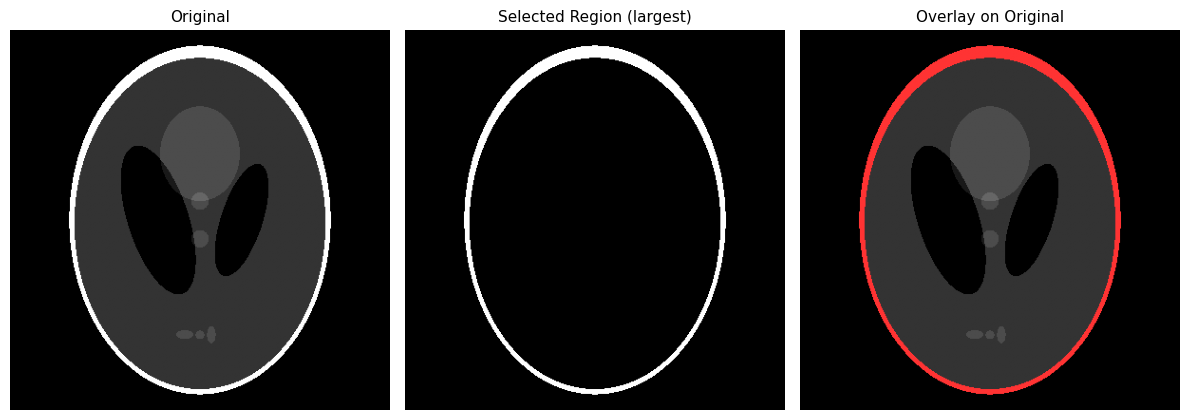

In [12]:
# Region-property filtering — isolate the largest, most "blob-like" region
labeled = measure.label(otsu_mask)
props = measure.regionprops(labeled)

candidates = [p for p in props if p.area > 50]
candidates.sort(key=lambda p: p.area, reverse=True)

print(f"Found {len(props)} regions, {len(candidates)} above area threshold.")
for p in candidates[:5]:
    print(f"  label={p.label:3d}  area={p.area:6.0f}  eccentricity={p.eccentricity:.3f}  "
          f"solidity={p.solidity:.3f}")

if candidates:
    target = candidates[0]
    target_mask = labeled == target.label
    overlay = color.gray2rgb(image)
    overlay[target_mask] = [1, 0.2, 0.2]
    show([image, target_mask, overlay],
         ['Original', 'Selected Region (largest)', 'Overlay on Original'])

## 7. Putting It All Together — a Mini Denoise → Enhance → Segment Pipeline

A realistic mini-pipeline you'd present as "the project" on a resume: start from a noisy scan,
denoise it, enhance contrast, segment the region of interest, then clean up the mask
morphologically and overlay the result on the original.


/tmp/ipykernel_575/3678733484.py:16: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean_mask = morphology.remove_small_objects(clean_mask, min_size=40)


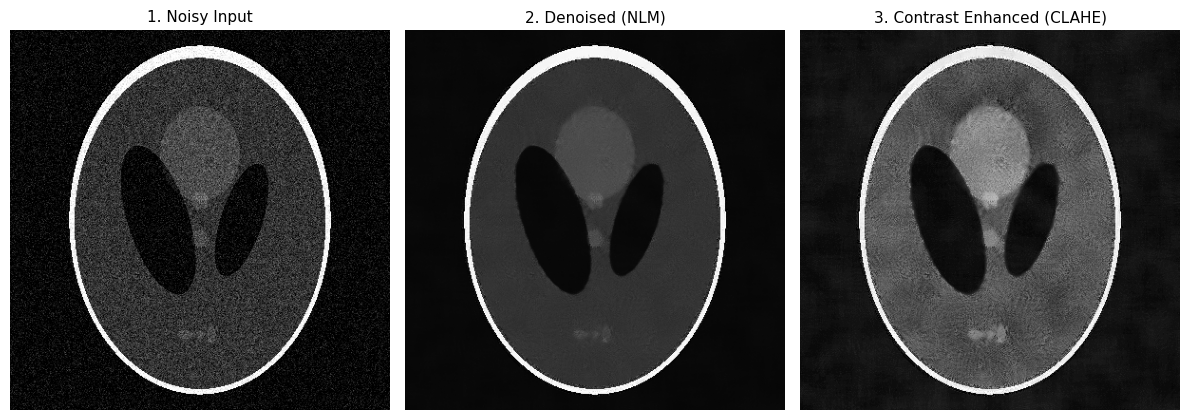

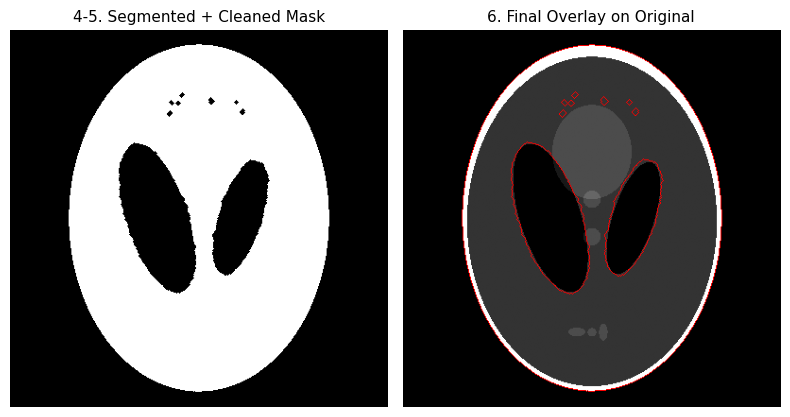

In [13]:
def dip_pipeline(img):
    # 1. Add realistic noise (simulating a noisy acquisition)
    noisy = random_noise(img, mode='gaussian', var=0.008)

    # 2. Denoise
    denoised = restoration.denoise_nl_means(noisy, h=0.06, fast_mode=True)

    # 3. Contrast enhancement
    enhanced = exposure.equalize_adapthist(denoised, clip_limit=0.02)

    # 4. Segment
    mask = enhanced > filters.threshold_otsu(enhanced)

    # 5. Morphological cleanup
    clean_mask = morphology.closing(mask, morphology.disk(2))
    clean_mask = morphology.remove_small_objects(clean_mask, min_size=40)

    # 6. Overlay
    overlay = color.gray2rgb(img)
    boundary = clean_mask ^ morphology.erosion(clean_mask, morphology.disk(1))
    overlay[boundary] = [1, 0, 0]

    return noisy, denoised, enhanced, clean_mask, overlay

noisy, denoised, enhanced, clean_mask, overlay = dip_pipeline(image)

show([noisy, denoised, enhanced], ['1. Noisy Input', '2. Denoised (NLM)', '3. Contrast Enhanced (CLAHE)'])
show([clean_mask, overlay], ['4-5. Segmented + Cleaned Mask', '6. Final Overlay on Original'])